# Visualising the generated datasets

This notebook shows example trajectories from the two datasets used in the paper:

| Dataset | Paper | Generator | Input channels | Output channels |
|---|---|---|---|---|
| Simplified Henry | Sec. 5 | `generate_simplified_henry.sh` | $C_0$, $\beta_C$, $D_C$ | $C$, $h$ |
| Classical Henry | App. I | `generate_classical_henry.sh` | $C_0$, $Q$, $\beta_C$, $D_C$, $t$, $z$, $x$ | $C$, $h$ |

Each scenario (one $(\beta_C, D_C)$ pair) is stored as `scenario_NNN/scenario.npz` with
`input_tensor` of shape `(n_runs, C_in, T-1, nlay, ncol)` and `output_tensor` of shape `(n_runs, 2, T-1, nlay, ncol)`.
The trajectory below is rebuilt as $t_0 \dots t_{T-1}$, where $t_0$ is the initial condition $C_0$.
Head is not stored at $t_0$, so head strips start at $t_1$.

The outputs are saved in the notebook, so you can view the figures without running anything.
To re-run it, generate the datasets (see `README.md`) and set `HENRY_DATA_DIR` if they are not in `../data`.
Every figure is also saved as PDF and PNG in `figures/` (set `HENRY_FIG_DIR` to change this).

In [17]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATA_DIR       = Path(os.environ.get('HENRY_DATA_DIR', '../data'))
SIMPLIFIED_DIR = DATA_DIR / 'simplified_henry'
CLASSICAL_DIR  = DATA_DIR / 'classical_henry'
FIG_DIR        = Path(os.environ.get('HENRY_FIG_DIR', 'figures'))
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    # Save as PDF (vector text, for LaTeX) and 300-dpi PNG
    for ext in ('pdf', 'png'):
        fig.savefig(FIG_DIR / f'{name}.{ext}', dpi=300, bbox_inches='tight')


def load_manifest(dataset_dir):
    return json.load(open(dataset_dir / 'manifest.json'))


def scenario_path(dataset_dir, manifest, beta_c, diffc):
    # Path of the scenario.npz with the given (beta_c, diffc)
    for s in manifest['scenarios']:
        if np.isclose(s['beta_c'], beta_c) and np.isclose(s['diffc'], diffc):
            return dataset_dir / s['scenario'] / 'scenario.npz'
    raise KeyError(f'No scenario with beta_c={beta_c}, diffc={diffc}')


def trajectory(data, run_idx):
    # Concentration and head (T, nlay, ncol) for t_0 .. t_{T-1}; head at t_0 is NaN
    names = [str(s) for s in data['input_channel_names']]
    c0 = data['input_tensor'][run_idx, names.index('concentration_0'), :1]
    out = data['output_tensor'][run_idx]
    conc = np.concatenate([c0, out[0]], axis=0)
    head = np.concatenate([np.full_like(c0, np.nan), out[1]], axis=0)
    times = np.concatenate([[0.0], data['times_out']])
    return conc, head, times


def summarise(name, manifest):
    print(f'{name}')
    print(f'  scenarios : {manifest["n_scenarios"]}  '
          f'beta_c = {sorted({s["beta_c"] for s in manifest["scenarios"]})}  '
          f'D_C = {sorted({s["diffc"] for s in manifest["scenarios"]})}')
    print(f'  runs      : {manifest["n_ok_runs"]} ok, {manifest["n_failed_runs"]} failed')
    print(f'  grid      : {manifest["grid"]}')
    print(f'  time      : T = {manifest["time"]["total_time"]} d, {manifest["T_out"]} target frames, '
          f'dt = {manifest["dt_eff"]} d')
    print(f'  input     : {manifest["input_channel_names"]}')
    print(f'  output    : {manifest["output_channel_names"]}')


def sci(x):
    # 7e-05 -> '7\times10^{-5}' (mathtext without $)
    exp = int(np.floor(np.log10(abs(x)) + 1e-9))
    mant = x / 10**exp
    return f'10^{{{exp}}}' if np.isclose(mant, 1) else f'{mant:.2g}\\times10^{{{exp}}}'


def plot_strip(rows, frames, times, cmap, label, shared_scale, lx, lz, row_labels):
    # One row of frames per entry in `rows` (each an array (T, nlay, ncol)).
    # If the first frame is the input t_0, a wider gap separates it from the targets.
    FW, GAP, ROW_GAP = 1.0, 0.04, 0.12                 # frame width and gaps [in]
    IN_GAP = 0.2 if frames[0] == 0 else GAP            # gap after the input frame
    FH = FW * lz / lx                                  # physical aspect ratio
    LEFT, RIGHT, BOTTOM, TOP = 1.1, 0.95, 0.42, 0.05
    CB_PAD, CB_W = 0.1, 0.1
    n_rows = len(rows)
    x0 = [k * (FW + GAP) + (IN_GAP - GAP if k > 0 else 0) for k in range(len(frames))]
    W = LEFT + x0[-1] + FW + RIGHT
    H = BOTTOM + n_rows * FH + (n_rows - 1) * ROW_GAP + TOP
    fig = plt.figure(figsize=(W, H))
    add_ax = lambda x, y, w, h: fig.add_axes([x / W, y / H, w / W, h / H])
    row_y = [BOTTOM + (n_rows - 1 - r) * (FH + ROW_GAP) for r in range(n_rows)]

    if shared_scale:
        vmin = np.nanmin([np.nanmin(r[frames]) for r in rows])
        vmax = np.nanmax([np.nanmax(r[frames]) for r in rows])
    for r, series in enumerate(rows):
        if not shared_scale:
            vmin, vmax = np.nanmin(series[frames]), np.nanmax(series[frames])
        for k, t in enumerate(frames):
            ax = add_ax(LEFT + x0[k], row_y[r], FW, FH)
            im = ax.imshow(series[t], cmap=cmap, vmin=vmin, vmax=vmax,
                           aspect='auto', interpolation='nearest')
            ax.set_xticks([]); ax.set_yticks([])
        fig.text((LEFT - 0.08) / W, (row_y[r] + FH / 2) / H, row_labels[r],
                 ha='right', va='center', fontsize=7)
        if not shared_scale:
            cb = fig.colorbar(im, cax=add_ax(LEFT + x0[-1] + FW + CB_PAD, row_y[r], CB_W, FH))
            cb.ax.tick_params(labelsize=6)
    if shared_scale:
        cb = fig.colorbar(im, cax=add_ax(LEFT + x0[-1] + FW + CB_PAD, BOTTOM, CB_W, H - BOTTOM - TOP))
        cb.ax.tick_params(labelsize=7)
        cb.set_label(label, fontsize=9)

    for k, t in enumerate(frames):
        fig.text((LEFT + x0[k] + FW / 2) / W, (BOTTOM - 0.06) / H, f'{times[t]:.2f}',
                 ha='center', va='top', fontsize=7)
    fig.text((LEFT + (x0[-1] + FW) / 2) / W, 0.03 / H, 'Time [d]', ha='center', va='bottom', fontsize=9)
    return fig

## 1 · Simplified Henry problem (Sec. 5)

No inflow and $C = 0$ on every boundary. Flow is driven only by buoyancy, and the solute mass is flushed out through the boundaries.

In [18]:
simp_manifest = load_manifest(SIMPLIFIED_DIR)
summarise('Simplified Henry', simp_manifest)
LX_S, LZ_S = simp_manifest['grid']['lx'], simp_manifest['grid']['lz']

Simplified Henry
  scenarios : 16  beta_c = [2e-05, 7e-05, 0.00025, 0.001]  D_C = [0.001, 0.003, 0.01, 0.03]
  runs      : 6400 ok, 0 failed
  grid      : {'ncol': 40, 'nlay': 20, 'lx': 2.0, 'lz': 1.0}
  time      : T = 1.0 d, 25 target frames, dt = 0.04 d
  input     : ['concentration_0', 'beta_c', 'diffc']
  output    : ['concentration', 'head']


### 1a · One trajectory (Fig. 1)

$\beta_C = 7\times10^{-5}$ m³/kg, $D_C = 3\times10^{-3}$ m²/d, shown at 0.2 d intervals.

GRF of C0: {'random_field_len_scale': 0.1, 'random_field_var': 0.1}


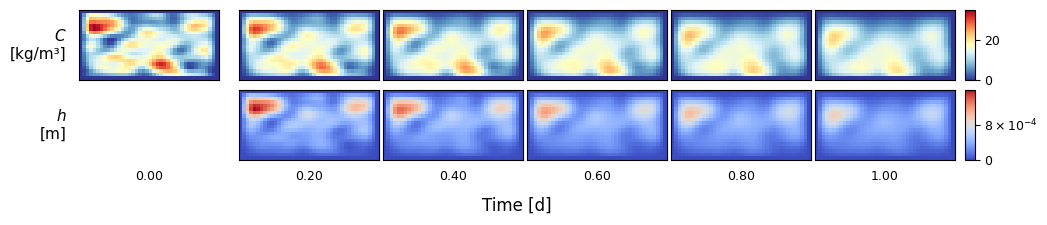

In [19]:
from matplotlib.ticker import FuncFormatter, MaxNLocator

RUN_IDX = 10
data = np.load(scenario_path(SIMPLIFIED_DIR, simp_manifest, 7e-5, 3e-3))
conc, head, times = trajectory(data, RUN_IDX)
frames = np.arange(0, len(times), 5)                       # every 0.2 d
run_params = json.loads(str(data['run_params'][RUN_IDX]))
print('GRF of C0:', {k: run_params[k] for k in ('random_field_len_scale', 'random_field_var')})

# ── Layout in inches: input frame t_0, a wider gap, then the target frames ──
FW, GAP, IN_GAP, ROW_GAP = 1.4, 0.04, 0.2, 0.1     # frame width and gaps
FH = FW * LZ_S / LX_S                               # physical aspect ratio
LEFT, RIGHT, BOTTOM, TOP = 0.9, 0.85, 0.6, 0.05
CB_PAD, CB_W = 0.1, 0.1
x0 = [k * (FW + GAP) + (IN_GAP - GAP if k > 0 else 0) for k in range(len(frames))]
W = LEFT + x0[-1] + FW + RIGHT
H = BOTTOM + 2 * FH + ROW_GAP + TOP
fig = plt.figure(figsize=(W, H))
add_ax = lambda x, y, w, h: fig.add_axes([x / W, y / H, w / W, h / H])

rows = [(conc, 'RdYlBu_r', '$C$\n[kg/m³]'), (head, 'coolwarm', '$h$\n[m]')]
for r, (field, cmap, label) in enumerate(rows):
    y = BOTTOM + (1 - r) * (FH + ROW_GAP)
    vmin, vmax = np.nanmin(field[frames]), np.nanmax(field[frames])   # shared over time
    for k, t in enumerate(frames):
        if np.all(np.isnan(field[t])):          # head is not stored at t_0
            continue
        ax = add_ax(LEFT + x0[k], y, FW, FH)
        im = ax.imshow(field[t], cmap=cmap, vmin=vmin, vmax=vmax,
                       aspect='auto', interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
    fig.text((LEFT - 0.12) / W, (y + FH / 2) / H, label, ha='right', va='center', fontsize=11)
    cb = fig.colorbar(im, cax=add_ax(LEFT + x0[-1] + FW + CB_PAD, y, CB_W, FH))
    cb.ax.tick_params(labelsize=9)
    if field is head:
        cb.locator = MaxNLocator(nbins=2)
        cb.formatter = FuncFormatter(lambda v, _: '0' if v == 0 else f'${sci(v)}$')
        cb.update_ticks()

for k, t in enumerate(frames):
    fig.text((LEFT + x0[k] + FW / 2) / W, (BOTTOM - 0.1) / H, f'{times[t]:.2f}',
             ha='center', va='top', fontsize=9)
fig.text((LEFT + (x0[-1] + FW) / 2) / W, 0.05 / H, 'Time [d]', ha='center', va='bottom', fontsize=12)
save_fig(fig, 'simplified_trajectory')
plt.show()

### 1b · Weakest and strongest coupling and diffusion (App. H, Fig. 5)

The same run index in the four corner scenarios $\{2\times10^{-5}, 10^{-3}\}\ \beta_C \times \{10^{-3}, 3\times10^{-2}\}\ D_C$.
Every scenario has its own random $C_0$, drawn from the same GRF statistics.
Concentration uses one colour scale. Head magnitude grows with $\beta_C$, so each head row has its own scale.

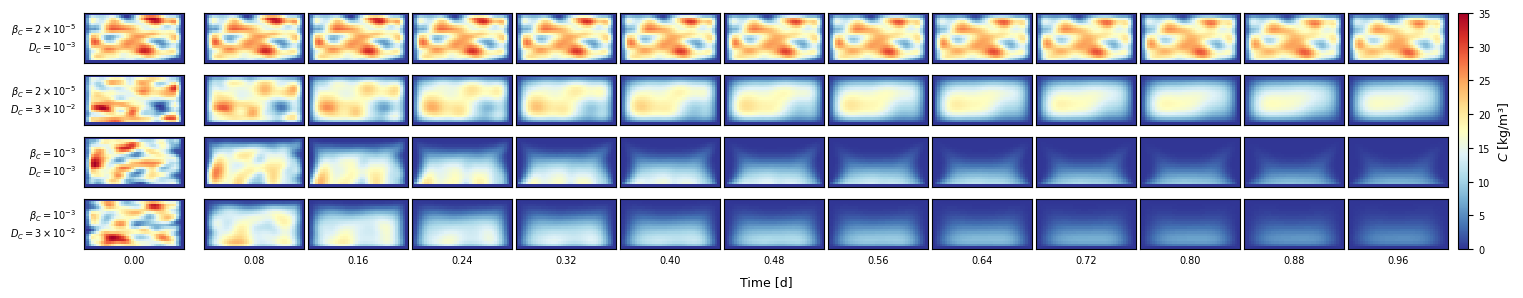

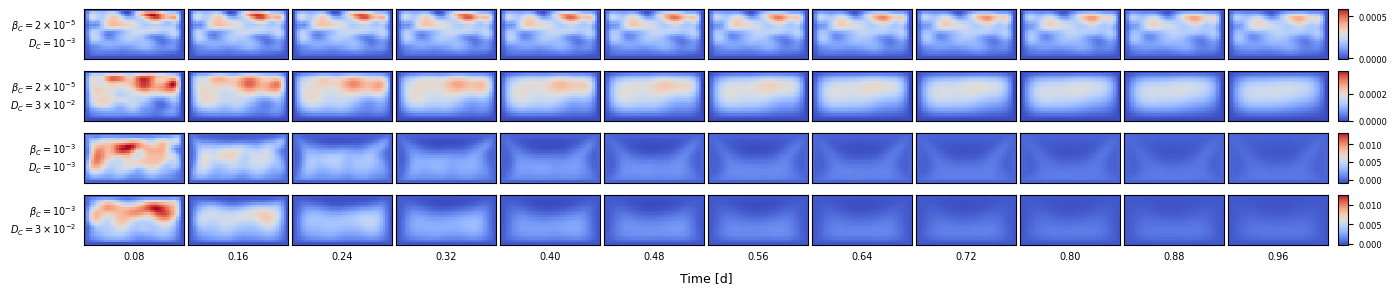

In [20]:
RUN_IDX = 0
CORNERS = [(2e-5, 1e-3), (2e-5, 3e-2), (1e-3, 1e-3), (1e-3, 3e-2)]

concs, heads, labels = [], [], []
for b, dc in CORNERS:
    d = np.load(scenario_path(SIMPLIFIED_DIR, simp_manifest, b, dc))
    c, h, times = trajectory(d, RUN_IDX)
    concs.append(c); heads.append(h)
    labels.append(f'$\\beta_C={sci(b)}$\n$D_C={sci(dc)}$')
frames = np.arange(0, len(times), 2)

fig = plot_strip(concs, frames, times, 'RdYlBu_r', r'$C$ [kg/m³]', True, LX_S, LZ_S, labels)
save_fig(fig, 'simplified_corners_concentration')
plt.show()
fig = plot_strip(heads, frames[frames > 0], times, 'coolwarm', r'$h$ [m]', False, LX_S, LZ_S, labels)
save_fig(fig, 'simplified_corners_head')
plt.show()

## 2 · Classical Henry problem (App. I)

There is a constant freshwater inflow $Q \sim \mathcal{U}[2, 6]$ m²/d on the left and a sea-level boundary with $C = 35$ kg/m³ on the right.
The random $C_0$ relaxes towards a persistent saltwater wedge.

In [21]:
clas_manifest = load_manifest(CLASSICAL_DIR)
summarise('Classical Henry', clas_manifest)
LX_C, LZ_C = clas_manifest['grid']['lx'], clas_manifest['grid']['lz']
HK, C_SEA = clas_manifest['pde']['hk'], clas_manifest['pde']['c_sea']

Classical Henry
  scenarios : 12  beta_c = [0.00035, 0.0007, 0.0014]  D_C = [0.05, 0.1, 0.3, 0.57024]
  runs      : 4800 ok, 0 failed
  grid      : {'ncol': 40, 'nlay': 20, 'lx': 2.0, 'lz': 1.0}
  time      : T = 0.25 d, 25 target frames, dt = 0.01 d
  input     : ['concentration_0', 'inflow', 'beta_c', 'diffc', 'coord_t', 'coord_z', 'coord_x']
  output    : ['concentration', 'head']


### 2a · Weakest and strongest coupling and diffusion (Fig. 8)

The same run index in the corner scenarios $\{3.5\times10^{-4}, 1.4\times10^{-3}\}\ \beta_C \times \{0.05, 0.57024\}\ D_C$.
Each row is labelled with its inflow $Q$ and Henry's dimensionless numbers $a = Q/(K \beta_C C_{sea} L_z)$ and $b = D_C/Q$.

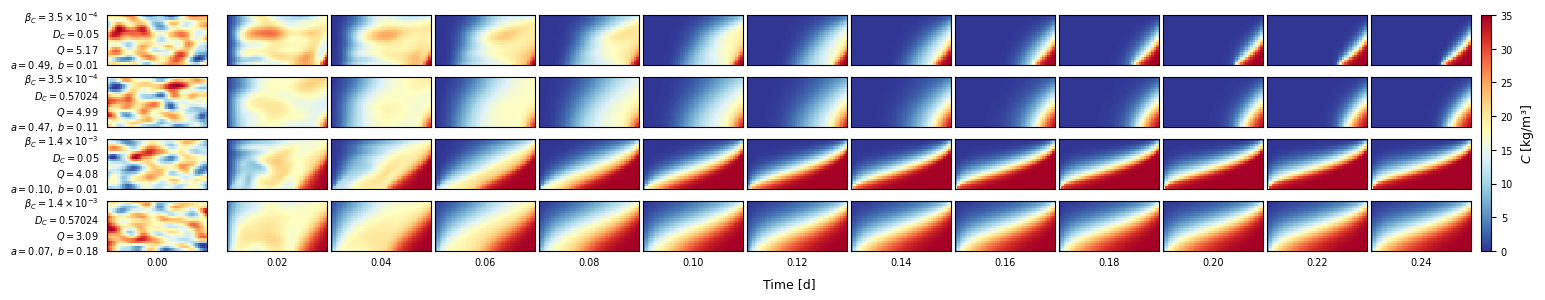

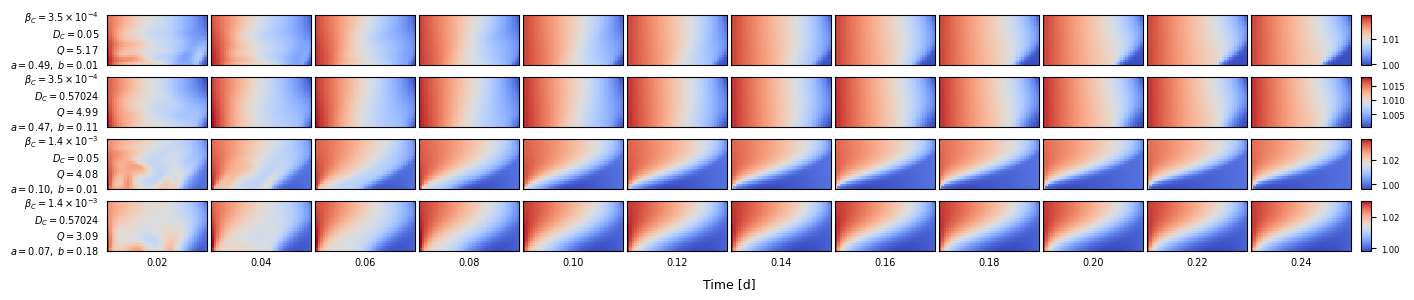

In [22]:
RUN_IDX = 0
CORNERS = [(3.5e-4, 0.05), (3.5e-4, 0.57024), (1.4e-3, 0.05), (1.4e-3, 0.57024)]

concs, heads, labels = [], [], []
for b, dc in CORNERS:
    d = np.load(scenario_path(CLASSICAL_DIR, clas_manifest, b, dc))
    c, h, times = trajectory(d, RUN_IDX)
    q = float(d['inflow'][RUN_IDX])
    concs.append(c); heads.append(h)
    labels.append(f'$\\beta_C={sci(b)}$\n$D_C={dc:g}$\n$Q={q:.2f}$\n'
                  f'$a={q / (HK * b * C_SEA * LZ_C):.2f},\\ b={dc / q:.2f}$')
frames = np.arange(0, len(times), 2)

fig = plot_strip(concs, frames, times, 'RdYlBu_r', r'$C$ [kg/m³]', True, LX_C, LZ_C, labels)
save_fig(fig, 'classical_corners_concentration')
plt.show()
fig = plot_strip(heads, frames[frames > 0], times, 'coolwarm', r'$h$ [m]', False, LX_C, LZ_C, labels)
save_fig(fig, 'classical_corners_head')
plt.show()

### 2b · Final wedge toe across the dataset

The toe $x_{toe}$ is where the 50% isochlor ($C = 17.5$ kg/m³) crosses the aquifer base, at the last frame ($t = 0.25$ d).
Plotted against Henry's $a$, the dependence on $\beta_C$ largely collapses. The dashed line marks the classical Henry value $a \approx 0.263$.

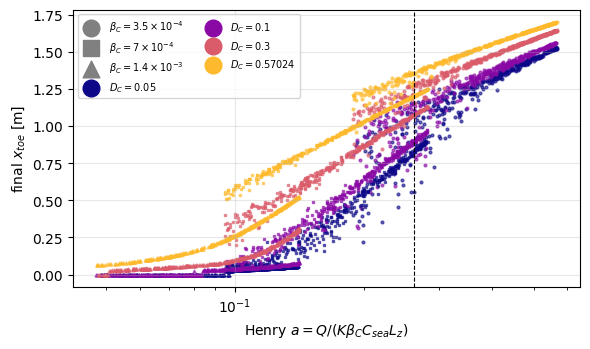

In [23]:
def toe_position(conc, level=0.5):
    # x where the `level`*C_SEA isochlor crosses the bottom row (interpolated); conc (..., nlay, ncol)
    base = conc[..., -1, :]
    x = (np.arange(base.shape[-1]) + 0.5) * LX_C / base.shape[-1]
    thr = level * C_SEA
    out = np.full(base.shape[:-1], np.nan)
    for idx in np.ndindex(base.shape[:-1]):
        row = base[idx]
        above = np.nonzero(row >= thr)[0]
        if above.size == 0:
            out[idx] = LX_C
        elif above[0] == 0:
            out[idx] = 0.0
        else:
            j = above[0]
            out[idx] = np.interp(thr, [row[j - 1], row[j]], [x[j - 1], x[j]])
    return out


markers = dict(zip(sorted({s['beta_c'] for s in clas_manifest['scenarios']}), ['o', 's', '^']))
diffcs = sorted({s['diffc'] for s in clas_manifest['scenarios']})
colors = {dc: plt.cm.plasma(0.85 * i / (len(diffcs) - 1)) for i, dc in enumerate(diffcs)}

fig, ax = plt.subplots(figsize=(6, 3.6))
for s in clas_manifest['scenarios']:
    d = np.load(CLASSICAL_DIR / s['scenario'] / 'scenario.npz')
    toe = toe_position(d['output_tensor'][:, 0, -1])
    a = d['inflow'] / (HK * s['beta_c'] * C_SEA * LZ_C)
    ax.scatter(a, toe, s=4, marker=markers[s['beta_c']], color=colors[s['diffc']], alpha=0.6)
for b, m in markers.items():
    ax.scatter([], [], marker=m, color='gray', label=f'$\\beta_C={sci(b)}$')
for dc, c in colors.items():
    ax.scatter([], [], marker='o', color=c, label=f'$D_C={dc:g}$')
ax.axvline(0.263, color='k', lw=0.8, ls='--')
ax.set(xscale='log', xlabel=r'Henry $a = Q / (K \beta_C C_{sea} L_z)$', ylabel=r'final $x_{toe}$ [m]')
ax.grid(alpha=0.3)
ax.legend(fontsize=7, markerscale=2, ncol=2)
plt.tight_layout()
save_fig(fig, 'classical_final_toe')
plt.show()